# 03 - Feature engineering

Turns corrected tracking into the feature tensor the classifiers consume, and
checks along the way that the features are worth consuming: not redundant, not
drifting within a session, not specific to one animal.

| § | Section | What it does |
|---|---------|--------------|
| §1 | Imports and logging | environment setup |
| §2 | Config | loads `configs/default.yaml` through Hydra |
| §3 | Load and correct | tracking plus skeleton correction |
| §4 | Extraction | `extract_features`: kinematic, Δz, relational |
| §5 | Train/val/test split | **before any diagnostic**, to avoid leakage |
| §6 | Imputation and validation | KNN and forward fill, NaN rate, assertions |
| §7 | Normalisation | check that body_length is about 1.0 |
| §8 | Redundancy | Pearson, mutual information, VIF, distance correlation |
| §9 | Kinematics | speed, angles, dorsal curvature |
| §10 | Δz per behaviour | implicit pose lifting |
| §11 | Relational features | inter-mouse distances and angles |
| §12 | Temporal validation | autocorrelation, smoothness, drift, entropy |
| §13 | PCA and UMAP | dimensionality reduction plus silhouette |
| §14 | Feature importance | random forest, permutation, SHAP |
| §15 | Stability | KS within video and between animals |
| §16 | Window dataset | the PyTorch `MouseBehaviorDataset` |
| §17 | HDF5 export | with full provenance metadata |

## §1 Imports and logging

In [1]:
import sys, logging
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import importlib
import src.data.feature_pipeline
import src.data.features
import src.data.dataset
import src.skeleton

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.data.feature_pipeline as fp

# ── Logging ───────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(name)s  %(levelname)s  %(message)s',
    datefmt='%H:%M:%S',
    force=True,
)
logger = logging.getLogger('03_features')

# ── Plot style ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110

logger.info('Entorno listo.')

16:41:58  03_features  INFO  Entorno listo.


## §2 Configuration

In [2]:
cfg = fp.load_config('../configs')

from omegaconf import OmegaConf
print(OmegaConf.to_yaml(cfg))

16:41:59  src.data.feature_pipeline  INFO  Config cargado desde C:\Users\User\dev\tfm\configs/default.yaml


data:
  lab: CalMS21_task1
  window_size: 64
  stride: 16
  min_window_fill: 0.75
  val_frac: 0.15
  test_frac: 0.15
  seed: 42
  include_background: false
training:
  epochs: 100
  batch_size: 64
  lr: 0.001
  weight_decay: 0.0001
  early_stopping_patience: 10
  clip_grad_norm: 1.0
  seed: 42
  device: auto
loss:
  type: focal
  focal_gamma: 2.0
  use_class_weights: true
  label_smoothing: 0.0
model:
  lstm:
    hidden_size: 128
    num_layers: 2
    dropout: 0.3
    bidirectional: true
  cnn_lstm:
    cnn_channels: 128
    cnn_layers: 3
    lstm_hidden: 128
    lstm_layers: 2
    dropout: 0.3
    bidirectional: true
    scheduler: one_cycle
    augment: true
baseline:
  random_forest:
    n_estimators: 300
    max_depth: null
    class_weight: balanced
  svm:
    C: 1.0
    class_weight: balanced
  gradient_boosting:
    max_iter: 300
    learning_rate: 0.1
    max_depth: 5
  cross_val_folds: 5
ablation:
  configs:
  - name: B1_raw_rf
    description: Keypoints brutos + RF (baseline 

In [3]:
# ── Summary of the active configuration ───────────────────────────────────
print(f"Video   : {cfg.video.lab} / {cfg.video.id}  ({cfg.video.fps} fps)")
print(f"Window  : W={cfg.data.window_size}  stride={cfg.data.stride}")
print(f"Split   : val={cfg.data.val_frac}  test={cfg.data.test_frac}  seed={cfg.data.seed}")
print(f"Impute  : strategy={cfg.features.imputation.strategy}  k={cfg.features.imputation.knn_k}")
print(f"Scaling : {cfg.features.scaling.method}  angles={cfg.features.scaling.angle_encoding}")
print(f"Embedding: PCA({cfg.features.embedding.pca_components}) → UMAP")
print(f"Version : {cfg.features.versioning.feature_version}")

Vídeo   : CalMS21_task1 / 13638642  (30 fps)
Ventana : W=64  stride=16
Split   : val=0.15  test=0.15  seed=42
Impute  : strategy=knn  k=5
Scaling : robust  angles=circular
Embedding: PCA(50) → UMAP
Version : 1.0.0


## §3 Loading and skeleton correction

In [4]:
df_corrected, skeleton, ann_df = fp.load_and_correct(cfg)

print(f'\nCorrected frames  : {df_corrected["video_frame"].nunique()}')
print(f'Mice              : {df_corrected["mouse_id"].nunique()}')
print(f'Keypoints         : {skeleton.keypoints}')
print(f'L_body_median_px  : {skeleton.L_body_median_px:.1f} px')
if ann_df is not None:
    print(f'Behaviours        : {sorted(ann_df["action"].unique())}')

16:41:59  src.data.feature_pipeline  INFO  Cargando tracking: lab=CalMS21_task1  video=13638642
16:41:59  src.data.feature_pipeline  INFO  Construyendo y ajustando esqueleto…
16:41:59  src.data.feature_pipeline  INFO  L_body_median_px = 175.5 px
16:41:59  src.data.feature_pipeline  INFO  Aplicando corrección esquelética (smooth_video)…
16:41:59  src.data.feature_pipeline  INFO  Corrección ← caché (hash=c30ea046ee, 6330 frames)



Frames corregidos : 6330
Ratones           : 2
Keypoints         : ['nose', 'neck', 'ear_left', 'ear_right', 'hip_left', 'hip_right', 'tail_base']
L_body_median_px  : 175.5 px
Comportamientos   : ['approach', 'mount', 'sniffbody', 'sniffface', 'sniffgenital']


## §4 Feature extraction

In [5]:
results = fp.extract_and_prepare(df_corrected, skeleton, ann_df, cfg)

# ── Breakdown by group ────────────────────────────────────────────────────
mid0    = sorted(results.keys())[0]
fnames  = results[mid0]['feature_names']
kps     = skeleton.keypoints

_kp_sfx    = ('_vx', '_vy', '_speed', '_accel')
centroid_g = [f for f in fnames if f.startswith('centroid_')]
body_g     = [f for f in fnames if f in ('body_angle', 'body_angle_vel', 'body_length')]
kp_g       = [f for f in fnames if any(f == f'{kp}{s}' for kp in kps for s in _kp_sfx)]
angle_g    = [f for f in fnames if 'angle' in f and 'body' not in f and 'relative' not in f]
dz_g       = [f for f in fnames if f.startswith('dz_')]
rel_names  = {'dist_centroid','dist_nose_nose','angle_relative','speed_relative',
              'approach_rate','facing_b','dz_centroid_diff','sniff_site_ratio'}
rel_g      = [f for f in fnames if f in rel_names]

print(f'\n── Feature breakdown ({len(fnames)} total) ──────────────')
print(f'  Centroid kinematics   : {len(centroid_g):3d}')
print(f'  Body angle/length     : {len(body_g):3d}  {body_g}')
print(f'  Per keypoint (x{len(kps)})     : {len(kp_g):3d}')
print(f'  Segment angles        : {len(angle_g):3d}  {angle_g[:3]}…')
print(f'  dz (pose lifting)     : {len(dz_g):3d}  {dz_g[:3]}…')
print(f'  Relational            : {len(rel_g):3d}  {rel_g[:3]}…')

16:41:59  src.data.feature_pipeline  INFO  Extrayendo features  W=64  stride=16 …
16:42:00  src.data.feature_pipeline  INFO  Mouse 1: features_df=(5763, 64)  X=(357, 64, 64)  y=(357,)
16:42:00  src.data.feature_pipeline  INFO  Mouse 2: features_df=(5763, 64)  X=(357, 64, 64)  y=(357,)



── Desglose de features (64 total) ──────────────
  Cinemáticas centroide :   9
  Ángulo/longitud cuerpo:   3  ['body_angle', 'body_angle_vel', 'body_length']
  Por keypoint (×7)     :  28
  Ángulos segmento      :   3  ['neck_spine_angle', 'hip_tail_angle_left', 'hip_tail_angle_right']…
  Δz (pose lifting)     :   9  ['dz_nose_neck', 'dz_neck_ear_left', 'dz_neck_ear_right']…
  Relacionales          :   8  ['dist_centroid', 'dist_nose_nose', 'sniff_site_ratio']…


## §5 Train, validation and test split

The split happens **before** any diagnostic or plot. Doing it the other way round
is how leakage gets in: once you have looked at the whole set to choose a feature,
the validation set is no longer independent of that choice.

In [6]:
split = fp.split_results(results, cfg)

print(f'Stratified split:')
print(f'  train : {len(split["idx_train"])} windows')
print(f'  val   : {len(split["idx_val"])} windows')
print(f'  test  : {len(split["idx_test"])} windows')
print(f'  total : {len(split["X_all"])} windows')

if split['y_train'] is not None:
    unique, counts = np.unique(split['y_train'], return_counts=True)
    print(f'\nClasses in train: {len(unique)}')
    for lbl, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
        print(f'  {lbl:20s}: {cnt:4d}')

16:42:00  src.data.feature_pipeline  INFO  Split: train=249  val=54  test=54  (N=357)


Split estratificado:
  train : 249 ventanas
  val   : 54 ventanas
  test  : 54 ventanas
  total : 357 ventanas

Clases en train: 6
  background          :  104
  sniffbody           :   51
  mount               :   29
  approach            :   22
  sniffgenital        :   22
  sniffface           :   21


## §6 Imputation and validation

Three strategies, one per kind of feature: **KNN** for kinematics, **forward fill**
for angular series, where interpolating across the wrap-around would invent
rotations, and **zero** for relational features that do not exist in single-mouse
videos.

In [7]:
results = fp.impute_features(results, cfg)

# ── Shape and finiteness validation ──────────────────────────────────────
val_report = fp.validate_features(results, split)

print(f'\nFeatures with NaN > 5% (after imputation): {len(val_report["high_nan_features"])}')
if len(val_report['high_nan_features']) > 0:
    print(val_report['high_nan_features'].head(10).to_string())
print(f'\nTrain windows : {val_report["n_windows_train"]}')
print('Assertions OK ✓')

16:42:00  src.data.feature_pipeline  INFO  Imputando NaN  strategy=knn …
16:42:01  src.data.feature_pipeline  INFO  NaN restantes tras imputación: 0
16:42:01  src.data.feature_pipeline  INFO  Features con NaN > 5%: 0 / 64
16:42:01  src.data.feature_pipeline  INFO  Finitud en X_train: 100.00%



Features con NaN > 5% (post-imputación): 0

Ventanas train : 249
Assertions OK ✓


## §7 Normalisation check

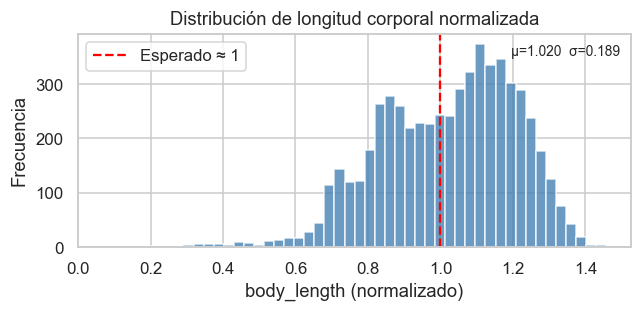

In [8]:
fp.plot_normalization_validation(results)

## §8 Redundancy

Computed on the **training split only**, for the same reason as §5.

- **Pearson**: linear correlation, catches the obvious collinearity
- **Mutual information**: non-linear dependence with the label
- **VIF**: multivariate collinearity, which pairwise correlation misses
- **Distance correlation**, optional: a non-linear generalisation of Pearson

In [9]:
# ── Build the flat features (window_statistics) over the split ────────────
X_flat_train, X_flat_val, X_flat_test, flat_names = fp.build_flat_features(
    results, split, cfg
)

# Scale, without PCA: this set feeds classification and the diagnostics
scaler_pipe = fp.build_scaling_pipeline(cfg, include_pca=False)
X_tr_sc, X_val_sc, X_te_sc = fp.fit_transform_split(
    scaler_pipe, X_flat_train, X_flat_val, X_flat_test
)
print(f'X_flat: train={X_flat_train.shape}  val={X_flat_val.shape}  test={X_flat_test.shape}')
print(f'flat_names: {flat_names[:6]} …  ({len(flat_names)} total)')

# ── Redundancy analysis ───────────────────────────────────────────────────
redundancy = fp.analyze_redundancy(X_tr_sc, flat_names, split['y_train'], cfg)
print(f'\nPairs with |r| > {cfg.features.redundancy.pearson_threshold}: '
      f'{len(redundancy["high_pairs"])}')
for c1, c2, r in redundancy['high_pairs'][:8]:
    print(f'  {c1[:35]:35s} ↔ {c2[:35]:35s}  r={r:+.3f}')

16:42:10  src.data.feature_pipeline  INFO  X_flat shapes: train=(249, 576)  val=(54, 576)  test=(54, 576)
16:42:10  src.data.feature_pipeline  INFO  Calculando correlación de Pearson…


X_flat: train=(249, 576)  val=(54, 576)  test=(54, 576)
flat_names: ['centroid_x_mean', 'centroid_y_mean', 'centroid_vx_mean', 'centroid_vy_mean', 'centroid_speed_mean', 'centroid_ax_mean'] …  (576 total)


16:42:15  src.data.feature_pipeline  INFO  Pares con |r| > 0.90: 384
16:42:15  src.data.feature_pipeline  INFO  Calculando mutual information…
16:42:19  src.data.feature_pipeline  INFO  Calculando VIF…
16:43:07  src.data.feature_pipeline  INFO  Features con VIF > 10: 550



Pares con |r| > 0.9: 384
  centroid_speed_mean                 ↔ centroid_speed_p75                   r=+0.989
  neck_accel_mean                     ↔ neck_accel_p75                       r=+0.987
  centroid_jerk_mean                  ↔ centroid_jerk_p75                    r=+0.986
  centroid_accel_mean                 ↔ centroid_accel_p75                   r=+0.986
  ear_left_accel_mean                 ↔ ear_left_accel_p75                   r=+0.985
  dist_centroid_mean                  ↔ dist_centroid_p75                    r=+0.985
  centroid_ax_p25                     ↔ centroid_ax_iqr                      r=-0.982
  dist_centroid_std                   ↔ approach_rate_std                    r=+0.980


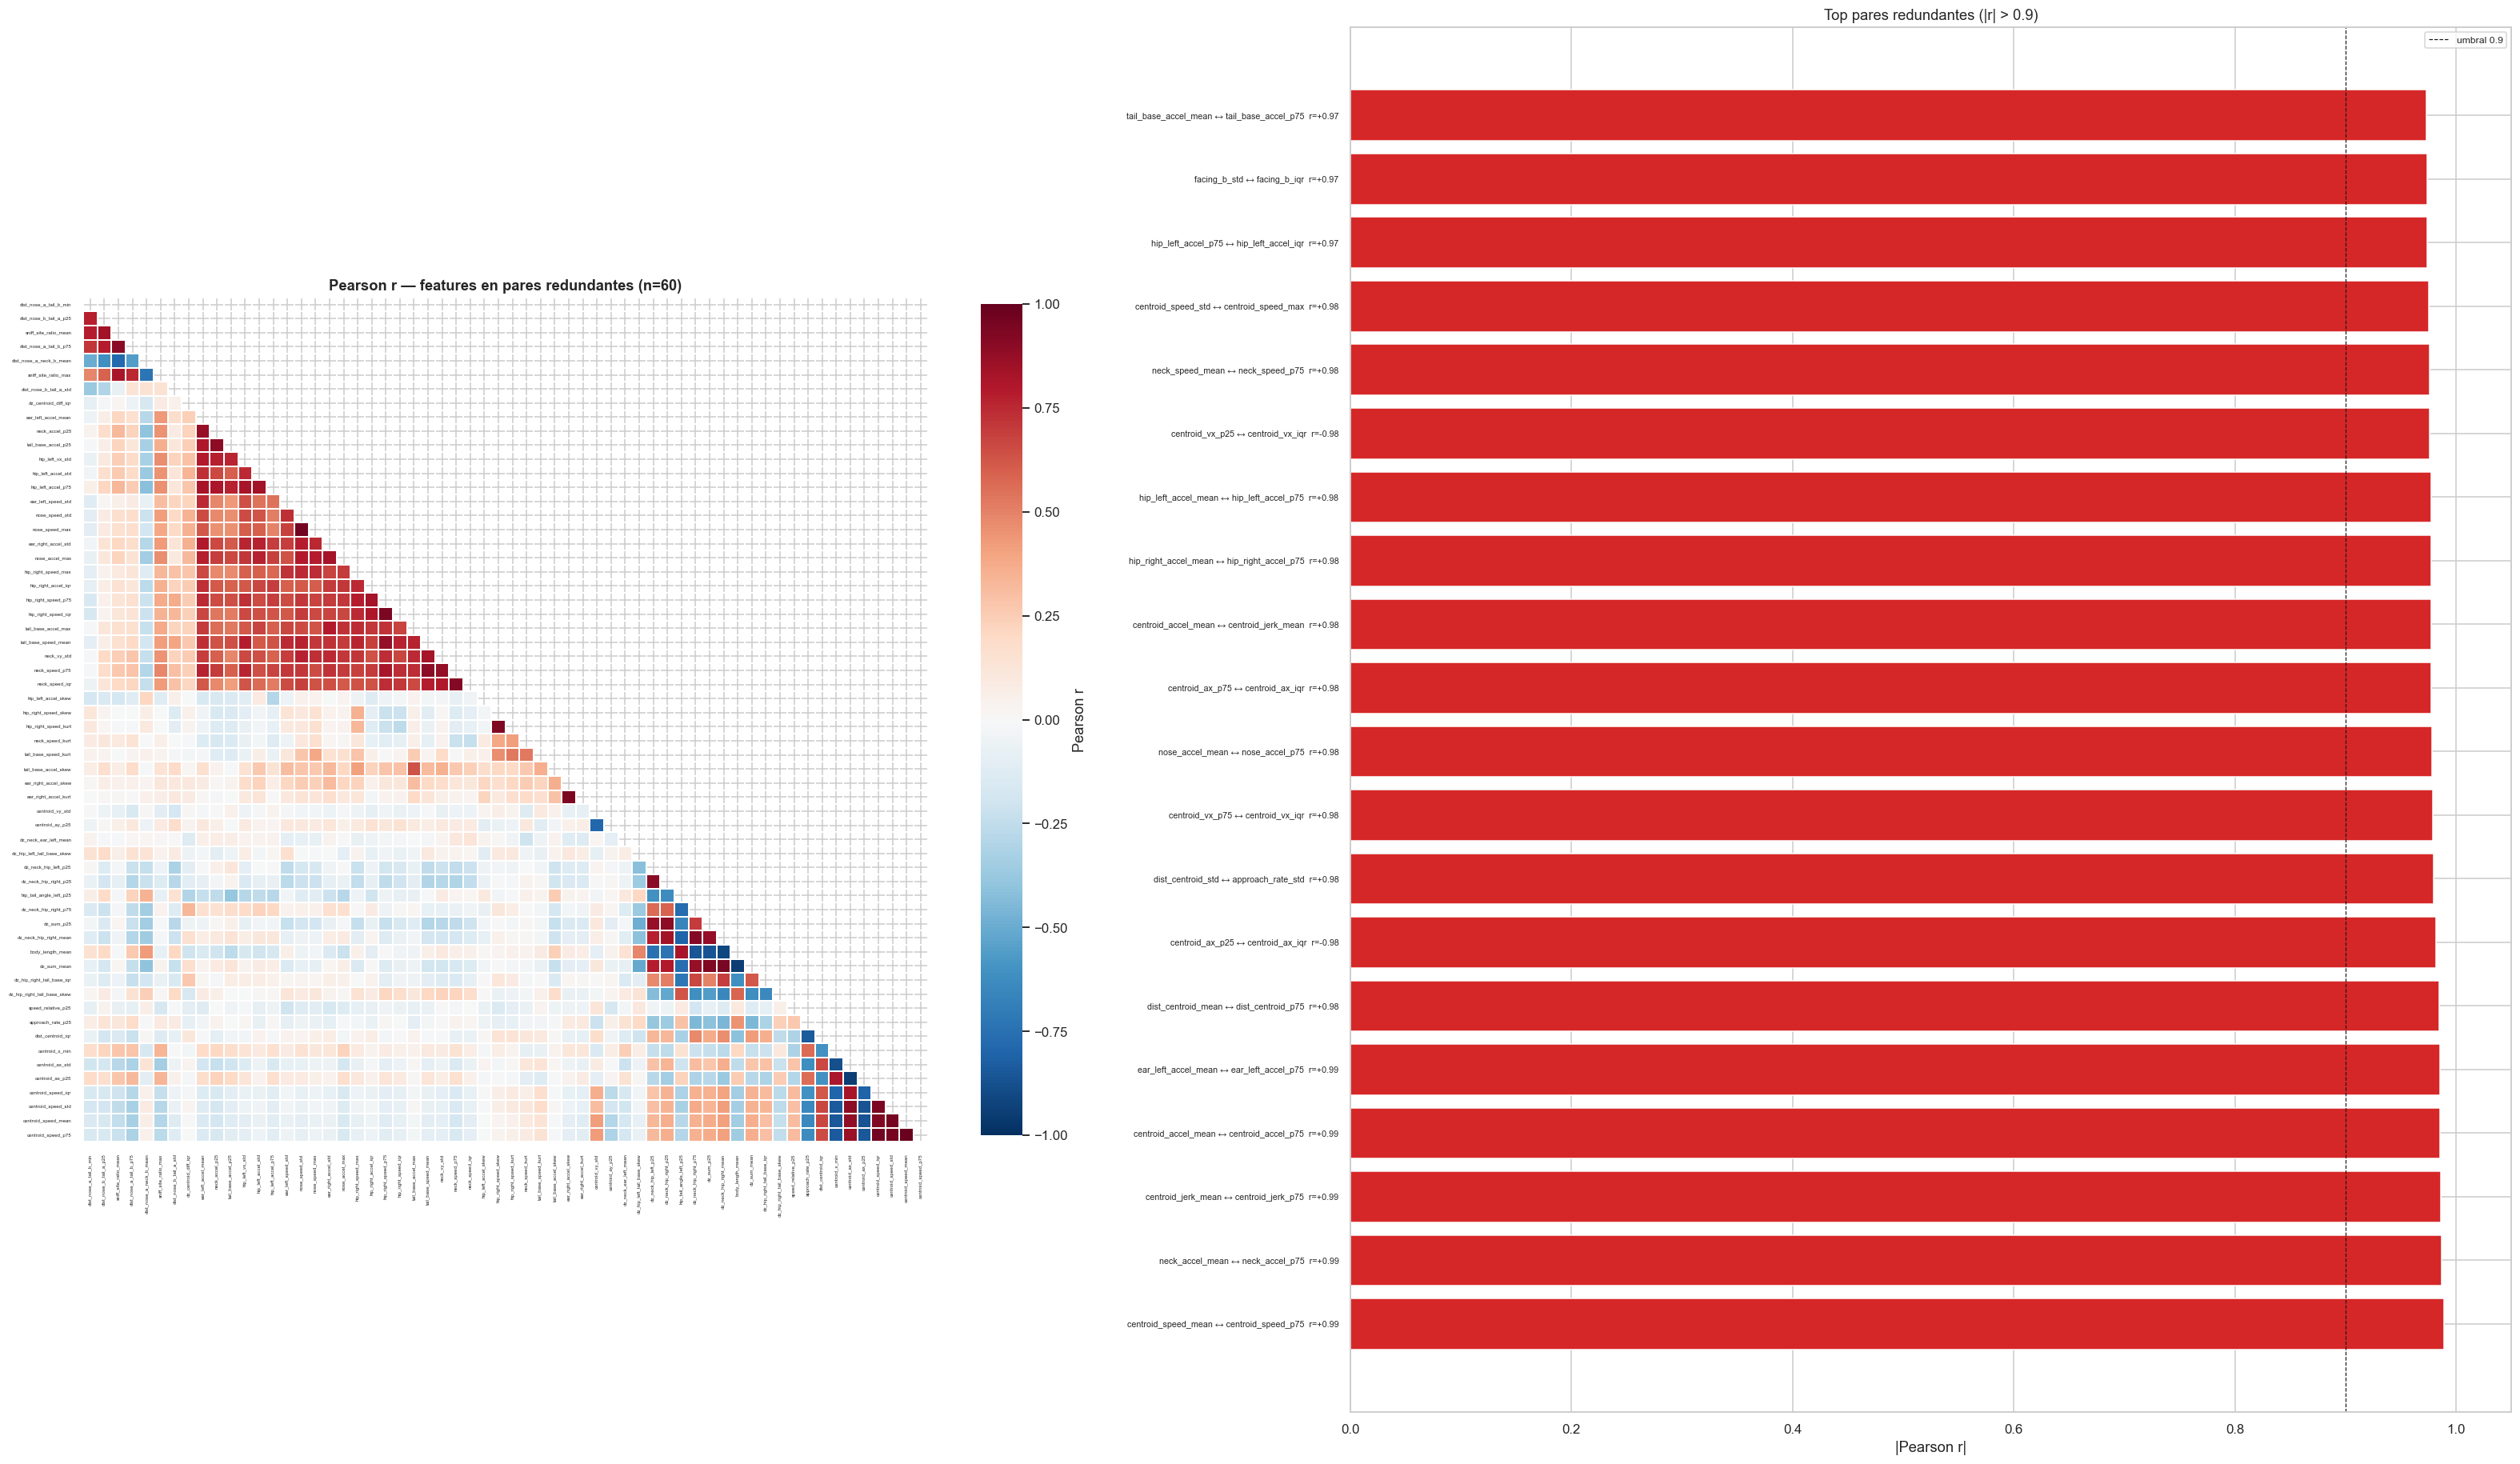

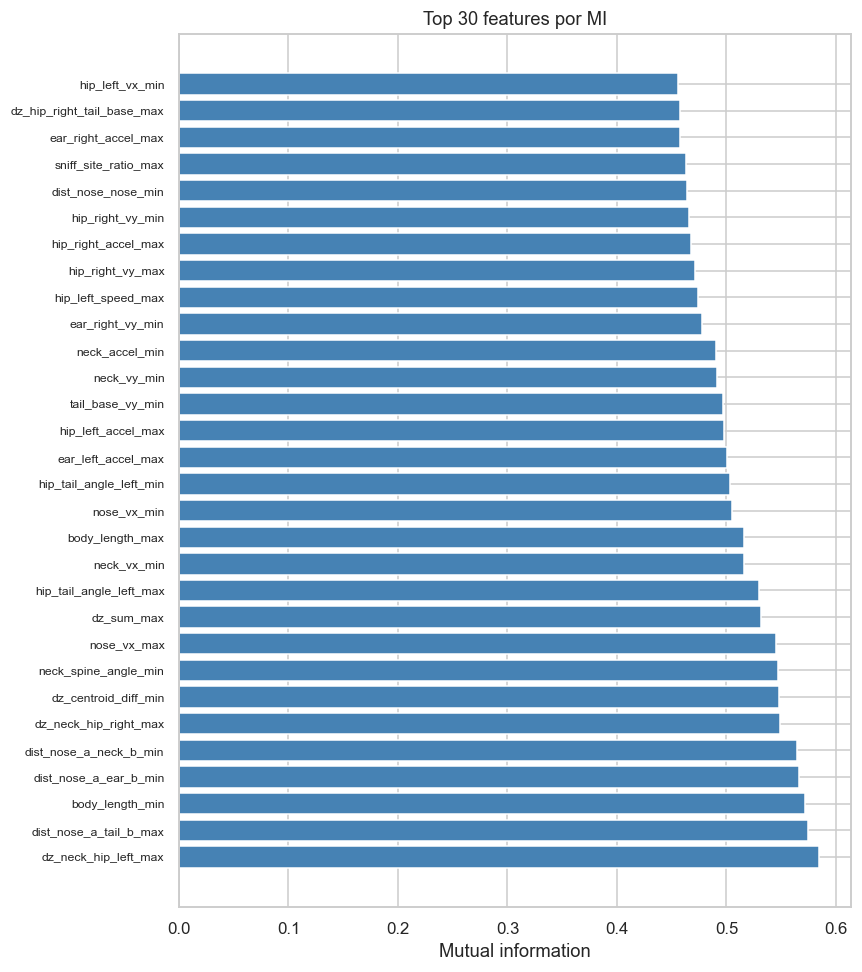

In [10]:
fp.plot_redundancy_heatmap(
    redundancy['corr_matrix'],
    redundancy['high_pairs'],
    threshold=float(cfg.features.redundancy.pearson_threshold),
)
fp.plot_mi_barplot(redundancy['mi_scores'], top_n=30)

## §9 Kinematics: speed and orientation

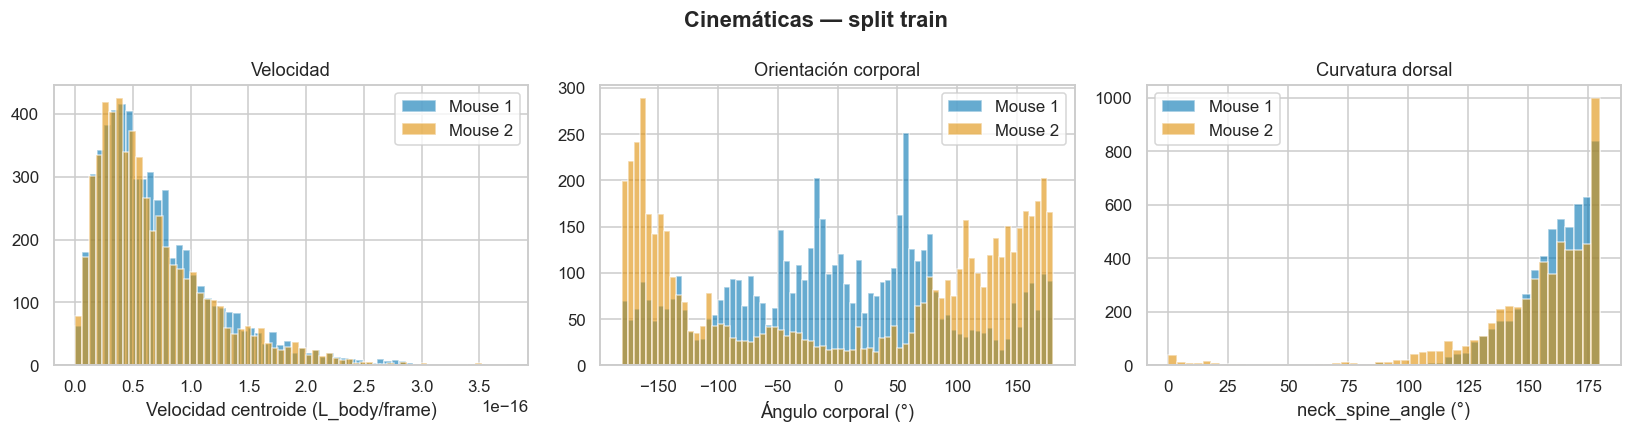

In [11]:
fp.plot_kinematics(results, split, cfg)

## §10 Δz features per behaviour

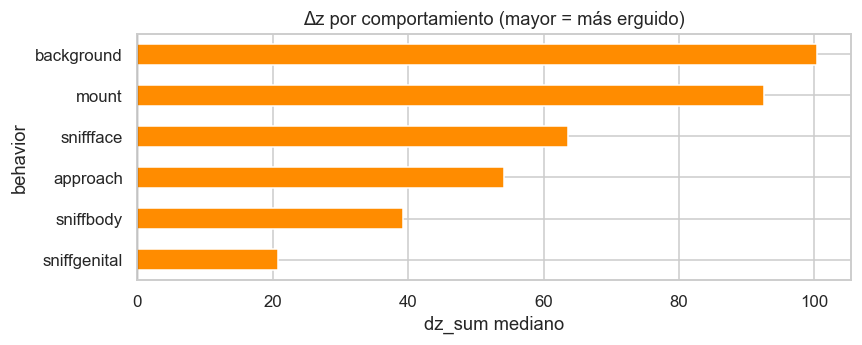

In [12]:
fp.plot_dz_by_behavior(results, split)

## §11 Relational features

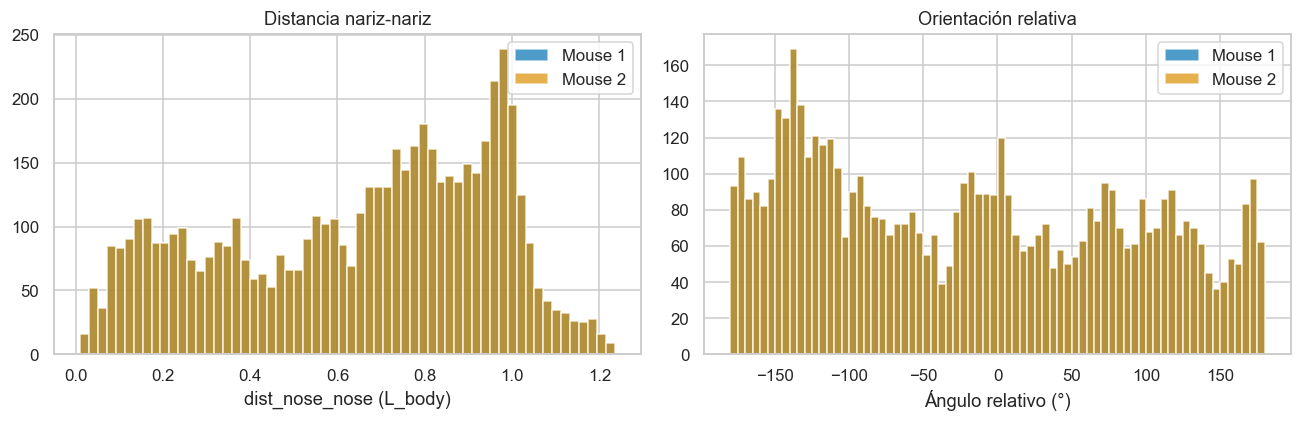

In [13]:
fp.plot_relational_features(results, split)

## §12 Temporal validation

Frame-level temporal properties, on the training split:

- **Lag-1 autocorrelation**: a high value means consecutive windows carry the same
  information, which inflates any evaluation that splits windows at random
- **Smoothness**, `var(Δx)/var(x)`: low means a smooth signal without spikes
- **Drift KS**: first 20% of the video against the last 20%, to catch within-session
  drift
- **Transition entropy**: how varied the behaviour is in this video

16:43:13  src.data.feature_pipeline  INFO  Features con drift significativo (p<0.05): 61 / 64
16:43:13  src.data.feature_pipeline  INFO  Transition entropy: 2.277 bits  (clases: 6)


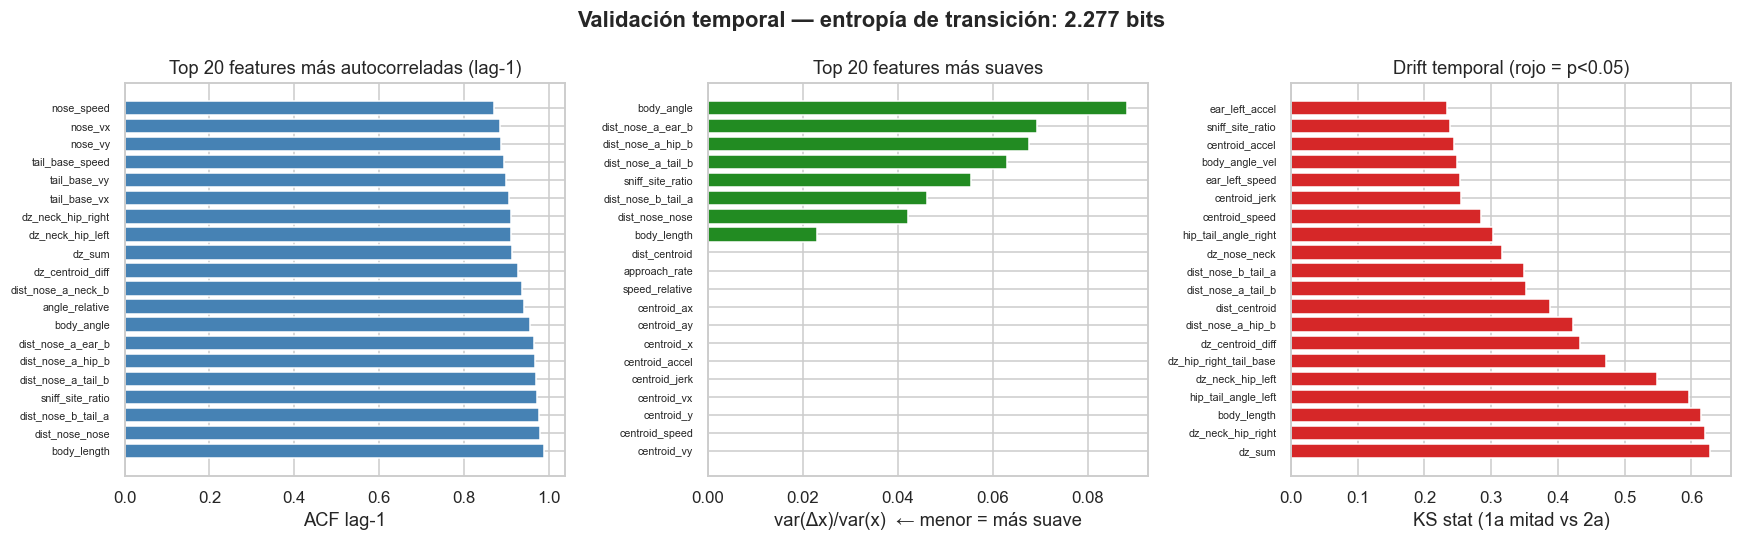


Transition entropy : 2.277 bits
Features con drift  (p<0.05): 61 / 64


In [14]:
temporal = fp.validate_temporal(results, split)
fp.plot_temporal_validation(temporal)

print(f'\nTransition entropy : {temporal["transition_entropy"]:.3f} bits'
      if temporal['transition_entropy'] is not None else '\nTransition entropy : N/A')
print(f'Features with drift (p<0.05): '
      f'{int((temporal["drift_df"]["p_value"] < 0.05).sum())} / '
      f'{len(temporal["drift_df"])}')

## §13 PCA and UMAP

A visual check on whether the classes separate at all in feature space.

1. **Scaler**, fitted on train only
2. **PCA to 50 components**, which removes noise and makes UMAP tractable
3. **UMAP to 2D**, a non-linear projection of the behaviour manifold

The silhouette score is computed in both the PCA and the UMAP space, because UMAP
exaggerates cluster separation and its silhouette alone would be misleading.

16:43:14  src.data.feature_pipeline  INFO  PCA(50) → dimensión original: 50 …
16:43:14  src.data.feature_pipeline  INFO  PCA varianza explicada (50 comp): 100.0%
16:43:14  src.data.feature_pipeline  INFO  Silhouette PCA: -0.075
16:43:47  src.data.feature_pipeline  INFO  UMAP finalizado.
16:43:47  src.data.feature_pipeline  INFO  Silhouette UMAP: -0.055


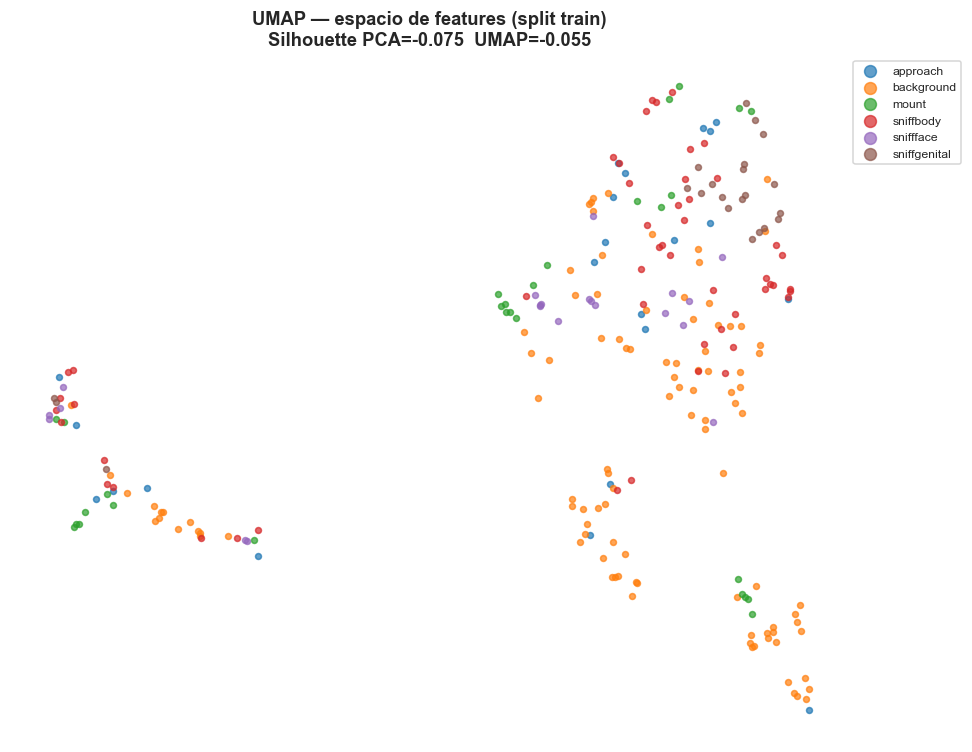

In [15]:
# Embedding pipeline: scaler plus PCA, fitted on train only
embed_pipe = fp.build_scaling_pipeline(cfg, include_pca=True)
X_tr_emb, _, _ = fp.fit_transform_split(
    embed_pipe, X_flat_train, X_flat_val, X_flat_test
)

emb_result = fp.compute_embeddings(
    X_tr_emb,
    split['y_train'],
    cfg,
)
fp.plot_embeddings(
    emb_result['emb_train'],
    split['y_train'],
    method=emb_result['method'],
    sil_pca=emb_result['sil_pca'],
    sil_emb=emb_result['sil_emb'],
)

## §14 Feature importance

Three views, because each has a known bias:

- **Random forest MDI**: fast, but biased towards high-cardinality features
- **Permutation importance** on the validation set: unbiased, and measures the
  effect on generalisation rather than on the fit
- **SHAP** with the tree explainer: per-prediction attribution

16:43:47  src.data.feature_pipeline  INFO  Entrenando RF para importancia de features…
16:43:48  src.data.feature_pipeline  INFO  RF accuracy (val): 0.667
16:43:48  src.data.feature_pipeline  INFO  Calculando permutation importance (n_repeats=10)…
16:45:14  src.data.feature_pipeline  INFO  Calculando SHAP (n=249)…
16:45:16  src.data.feature_pipeline  INFO  SHAP finalizado.


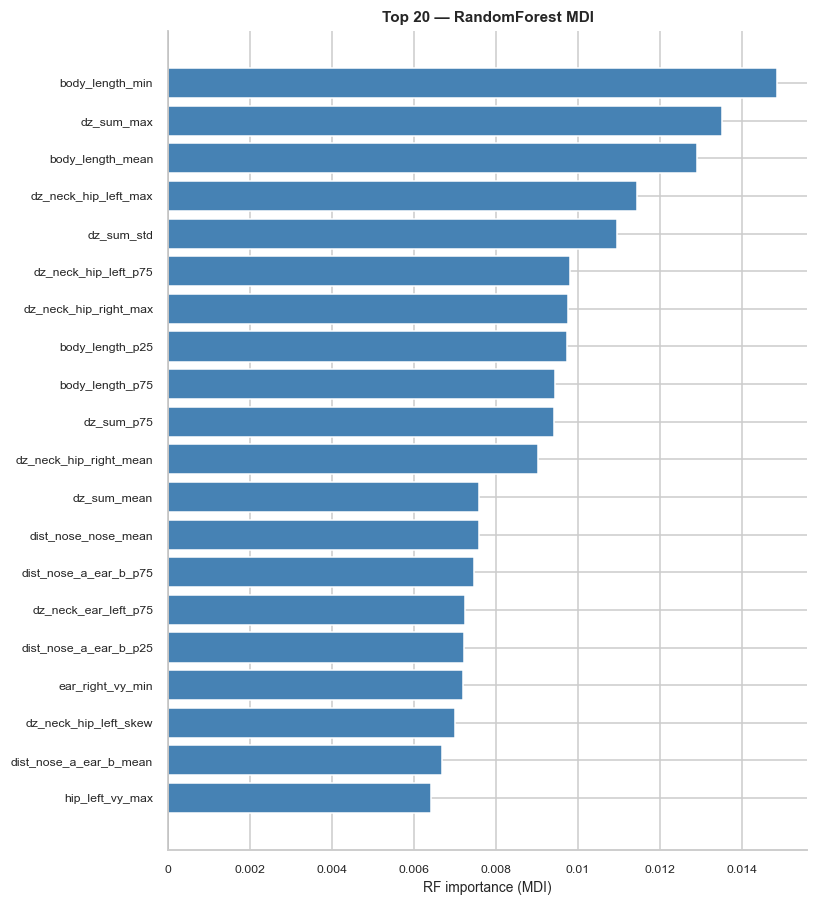

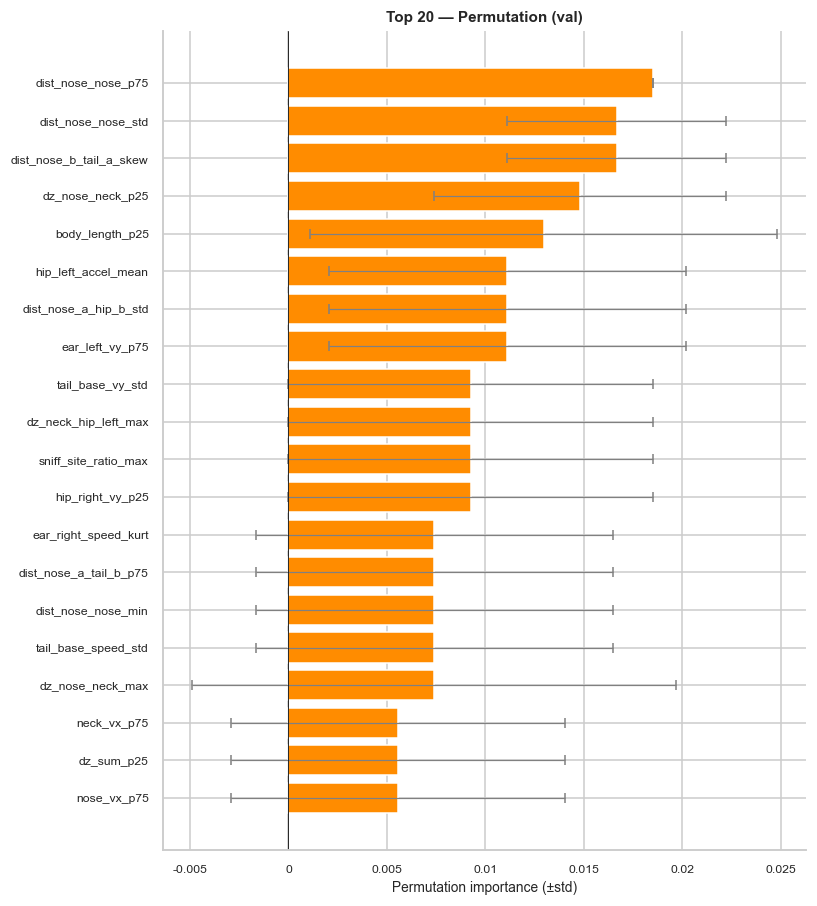

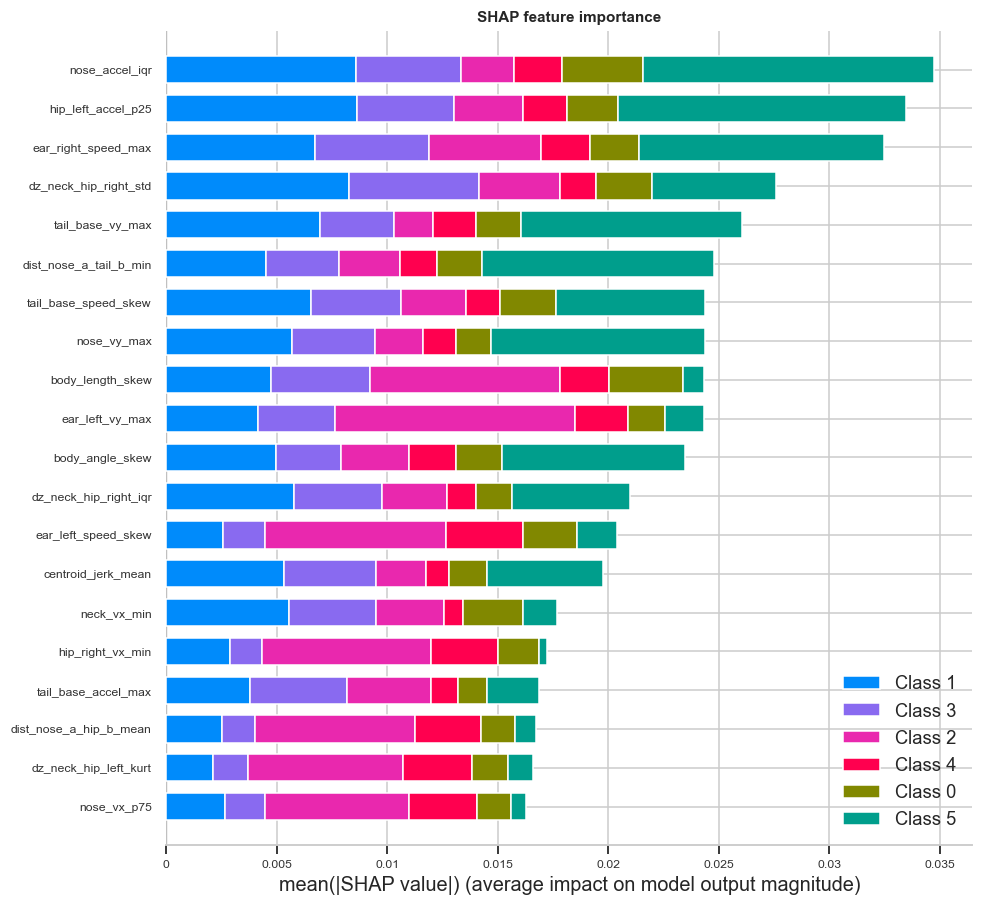


Top 10 features (RF MDI):
body_length_min          0.014862
dz_sum_max               0.013521
body_length_mean         0.012902
dz_neck_hip_left_max     0.011442
dz_sum_std               0.010967
dz_neck_hip_left_p75     0.009810
dz_neck_hip_right_max    0.009776
body_length_p25          0.009728
body_length_p75          0.009446
dz_sum_p75               0.009419


In [16]:
y_val_imp  = split['y_val']
y_train_imp = split['y_train']

if y_train_imp is not None and y_val_imp is not None and len(np.unique(y_train_imp)) > 1:
    importance = fp.compute_feature_importance(
        X_flat_train, y_train_imp,
        flat_names,
        X_flat_val,  y_val_imp,
        cfg,
    )
    fp.plot_feature_importance(importance, top_n=int(cfg.features.importance.top_n_features))
    print('\nTop 10 features (RF MDI):')
    print(importance['rf_importance'].head(10).to_string())
else:
    print('Importance not computed: not enough labels.')

## §15 Feature stability

- **Within video**: KS test between the first and second half, to catch drift
- **Between animals**: KS test across mice, where there are at least two, to catch
  features that describe one individual rather than the behaviour

Unstable features (p < 0.05) are the first suspects when a model fails to transfer
between labs, so they are flagged here rather than after the fact.

16:45:18  src.data.feature_pipeline  INFO  Features intra-vídeo inestables (p<0.05): 48 / 64
16:45:18  src.data.feature_pipeline  INFO  Features inter-animal distintas (p<0.05): 49 / 64


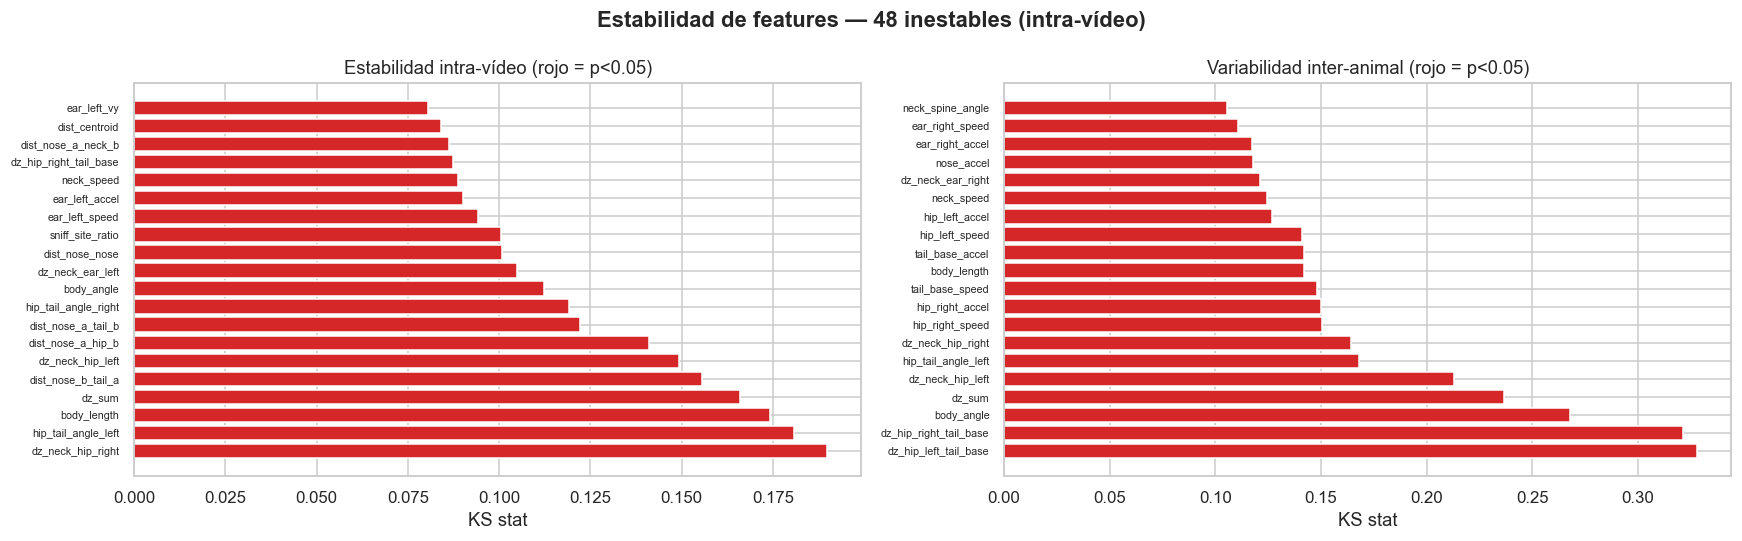


Features intra-vídeo inestables (p<0.05): 48
   ['dz_neck_hip_right', 'hip_tail_angle_left', 'body_length', 'dz_sum', 'dist_nose_b_tail_a', 'dz_neck_hip_left', 'dist_nose_a_hip_b', 'dist_nose_a_tail_b', 'hip_tail_angle_right', 'body_angle']


In [17]:
stability = fp.analyze_stability(results, split)
fp.plot_stability(stability)

print(f'\nIntra-video unstable features (p<0.05): '
      f'{len(stability["unstable_features"])}')
if stability['unstable_features']:
    print('  ', stability['unstable_features'][:10])

## §16 Window dataset

In [18]:
train_ds, val_ds, test_ds, enc = fp.build_window_dataset(results, split, cfg)

print(f'Datasets PyTorch:')
print(f' train : {len(train_ds)} windows')
print(f' val : {len(val_ds)} windows')
print(f' test : {len(test_ds)} windows')
print(f'\nClases ({len(enc.classes)} total): {enc.classes}')
print(f'Class weights: {train_ds.class_weights()}')

16:45:19  src.data.feature_pipeline  INFO  Datasets: train=51  val=10  test=11


Datasets PyTorch:
 train : 51 ventanas
 val : 10 ventanas
 test : 11 ventanas

Clases (8 total): ['sniff', 'attack', 'chase', 'escape', 'mount', 'approach', 'rear', 'selfgroom']
Pesos de clase: tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.8627, 1.1373])


## §17 HDF5 export with provenance

The file records how it was made, so that a cache found on disk months later can be
trusted or discarded on evidence rather than on memory:

| Field | Meaning |
|-------|---------|
| `feature_version` | semantic version of the pipeline |
| `git_commit` | commit hash at extraction time |
| `normalization` | coordinate normalisation method |
| `fps` | frame rate of the video |
| `sklearn_version` | scikit-learn version used |
| `numpy_version` | NumPy version |
| `extraction_timestamp` | UTC timestamp |
| `scaler_type` | scaler applied |
| `angle_encoding` | raw or circular |
| `split/train`, `split/val`, `split/test` | split indices |

In [19]:
out_path = fp.export_hdf5(results, split, scaler_pipe, cfg, out_dir='../dataset/features')

# ── Check the versioning metadata ────────────────────────────────────────
import h5py
with h5py.File(out_path, 'r') as hf:
    print(f'HDF5: {out_path}')
    print(f'  Size   : {out_path.stat().st_size / 1024:.1f} KB')
    print(f'\n── Versioning metadata ────────────────────────────')
    for key in ('feature_version', 'git_commit', 'normalization', 'fps',
                'sklearn_version', 'numpy_version', 'extraction_timestamp',
                'scaler_type', 'angle_encoding', 'window_size', 'stride'):
        print(f'  {key:25s}: {hf.attrs.get(key, "—")}')
    print(f'\n── Splits guardados ───────────────────────────────')
    for k in ('train', 'val', 'test'):
        print(f'  {k:5s}: {len(hf["split"][k])} windows')

16:45:19  src.data.feature_pipeline  INFO  HDF5 guardado: ..\dataset\features\CalMS21_task1_13638642_features.h5  (9905.3 KB)  git=149c6e1b92e4


HDF5: ..\dataset\features\CalMS21_task1_13638642_features.h5
  Tamaño : 9905.3 KB

── Metadatos de versioning ────────────────────────
  feature_version          : 1.0.0
  git_commit               : 149c6e1b92e4
  normalization            : l_body
  fps                      : 30
  sklearn_version          : 1.8.0
  numpy_version            : 2.4.4
  extraction_timestamp     : 2026-08-18T14:45:19.202801+00:00
  scaler_type              : robust
  angle_encoding           : circular
  window_size              : 64
  stride                   : 16

── Splits guardados ───────────────────────────────
  train: 249 ventanas
  val  : 54 ventanas
  test : 54 ventanas


## §Ex Multi-video event caches for 04, 05 and 06

Builds, or loads if they already exist, the
`CalMS21_task1_multi_20_event{,_raw,_surgical,_gentle}.npz` caches that notebooks
04, 05 and 06 read. This used to live in a separate script and now runs here.

By default only the missing caches are built, which is instant when they are
present. `RECOMPUTE=True` rebuilds everything: correcting 20 videos with L-BFGS-B
takes about an hour, less if the on-disk correction cache is warm.

In [20]:
# ── Building the multi-video event caches (20 videos) ─────────────────────────
# Self-contained (antes en scripts/build_event_cache.py + _prewarm_corrections.py).
# Notebooks 04/05/06 LOAD these caches. By default only the missing ones are built,
# which is fast when they already exist. RECOMPUTE=True forces a full rebuild: the
# L-BFGS correction over 20 videos takes about an hour, though it reuses the on-disk
# correction cache wherever it can.
import sys, pathlib, time
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None
import numpy as np
from src.data import features as F
from src.data.features import extract_features
from src.data.loader import load_tracking, load_annotations
from src.skeleton.mouse_skeleton import build_skeleton, fit_skeleton
from src.skeleton.config import skeleton_smooth_kwargs
from src.eval.mabe_metric import window_frame_spans

RECOMPUTE = False
LAB = "CalMS21_task1"; FEAT = _r / "dataset" / "features"
SRC = FEAT / "CalMS21_task1_multi_20_event.npz"        # defines the 20-video set + classes
# variant -> (suffix, skeleton config | None='raw', uncorrected | 'canonical')
VARIANTS = {"corrected": ("", "canonical"), "raw": ("_raw", None),
            "surgical": ("_surgical", "configs/skeleton_surgical.yaml"),
            "gentle":   ("_gentle",   "configs/skeleton_gentle.yaml")}

def _build_one(videos, classes, suffix, cfg):
    from src.skeleton.keypoint_smoother import smooth_video
    from src.data.correction_cache import load_or_correct
    cti = {c: i for i, c in enumerate(classes)}; out = FEAT / f"CalMS21_task1_multi_20_event{suffix}.npz"
    kw = None if cfg is None else skeleton_smooth_kwargs(path=(None if cfg == "canonical" else str(_r/cfg)))
    Xs, ys, vv, ag, tg, fs, fe = [], [], [], [], [], [], []
    for vid in videos:
        raw = load_tracking(vid, LAB)
        try: ann = load_annotations(vid, LAB); ann = ann if ann is not None and len(ann) else None
        except Exception: ann = None
        sk = build_skeleton(LAB); fit_skeleton(sk, raw)
        track = raw if cfg is None else load_or_correct(raw, LAB, str(vid), sk, kw)[0]
        res = extract_features(track, sk, ann); mice = sorted(res.keys())
        for mid in mice:
            r = res[mid]; Xm, ym, fdf = r["X"], r["y"], r["features_df"]
            if Xm is None or len(Xm) == 0 or ym is None: continue
            spans = window_frame_spans(fdf, F.WINDOW_SIZE, F.STRIDE, F.MIN_WINDOW_FILL)
            if len(spans) != len(Xm): continue
            other = next((m for m in mice if m != mid), -1) if len(mice) == 2 else -1
            for i in range(len(Xm)):
                lab = str(ym[i])
                if lab not in cti: continue
                Xs.append(Xm[i]); ys.append(cti[lab]); vv.append(str(vid)); ag.append(int(mid))
                tg.append(int(other)); fs.append(spans[i][0]); fe.append(spans[i][1])
    np.savez_compressed(out, X=np.asarray(Xs, np.float32), y=np.asarray(ys, np.int64),
        video_ids=np.asarray(vv, object), classes=np.asarray(classes),
        win_agent=np.asarray(ag, np.int64), win_target=np.asarray(tg, np.int64),
        win_fstart=np.asarray(fs, np.int64), win_fstop=np.asarray(fe, np.int64))
    print(f"  construida {out.name}  X={np.asarray(Xs).shape}")

if not SRC.exists() and not RECOMPUTE:
    print("Base cache multi_20_event.npz is missing; set RECOMPUTE=True to build everything.")
else:
    d = np.load(SRC, allow_pickle=True) if SRC.exists() else None
    videos = sorted(set(str(v) for v in d["video_ids"])) if d is not None else None
    classes = [str(c) for c in d["classes"]] if d is not None else None
    built = 0
    for name, (suf, cfg) in VARIANTS.items():
        p = FEAT / f"CalMS21_task1_multi_20_event{suf}.npz"
        if p.exists() and not RECOMPUTE:
            continue
        if videos is None:
            raise RuntimeError("No base cache to copy the video/class set from.")
        t0 = time.time(); print(f"Construyendo '{name}' ({suf or 'canonical'})…")
        _build_one(videos, classes, suf, cfg); built += 1; print(f"    ({time.time()-t0:.0f}s)")
    print("Caches ready." if built == 0 else f"Built {built} cache(s).")
    print("Presentes:", sorted(p.name for p in FEAT.glob("CalMS21_task1_multi_20_event*.npz")))

Cachés listas.
Presentes: ['CalMS21_task1_multi_20_event.npz', 'CalMS21_task1_multi_20_event_aug.npz', 'CalMS21_task1_multi_20_event_gentle.npz', 'CalMS21_task1_multi_20_event_noisycorr.npz', 'CalMS21_task1_multi_20_event_noisyraw.npz', 'CalMS21_task1_multi_20_event_raw.npz', 'CalMS21_task1_multi_20_event_surgical.npz', 'CalMS21_task1_multi_20_event_temporal.npz']


## §18 Feature selection

Feeds the diagnostics from §8 and §15 back into an actual selection over the
64 per-frame features the models consume, and writes `results/feature_selection.json`
for the LOVO benchmark to read.

The result is **56 of 64** kept, with no loss of F1. That is the useful finding:
eight features were carrying nothing, but removing them did not buy accuracy
either, only a smaller and more stable feature space.

In [21]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import json
import pandas as pd
from src.evaluation.lovo import load_cache, REPO
from src.data.feature_selection import select_features

X, y, vids, classes = load_cache()
_names_path = REPO / "results" / "feature_names_64.json"
names = json.loads(_names_path.read_text()) if _names_path.exists() else None
kept, diag = select_features(X, y, vids, names=names)
print(f"Kept {len(kept)}/{X.shape[-1]} features "
      f"(dropped {X.shape[-1]-len(kept)} by collinearity/VIF/stability)")

sel = {"kept_idx": kept, "kept_names": [d["feature"] for d in diag if d["kept"]],
       "n_kept": len(kept), "n_total": X.shape[-1]}
(REPO / "results" / "feature_selection.json").write_text(json.dumps(sel, indent=2))
pd.DataFrame(diag).query("not kept")[["feature", "vif", "drift", "max_abs_corr", "drop_reason"]]


Kept 56/64 features (dropped 8 by collinearity/VIF/stability)


,feature,vif,drift,max_abs_corr,drop_reason
9,nose_vx,1.000000e+09,1.503728,0.765822,vif=1000000000.0>10.0
10,nose_vy,1.000000e+09,1.052897,0.778137,vif=1000000000.0>10.0
43,dz_nose_neck,1.000000e+09,27.594047,0.461364,vif=1000000000.0>10.0
45,dz_neck_ear_right,1.000000e+09,45.052461,0.213832,unstable(drift=45.1) & low-mi(0.034)
52,dist_nose_nose,1.318926e+01,50.625666,0.911435,vif=10.8>10.0
53,dist_nose_a_tail_b,5.003932e+01,50.536788,0.961141,collinear(|r|>0.95) with sniff_site_ratio
57,dist_nose_a_hip_b,2.083143e+01,50.584217,0.950962,collinear(|r|>0.95) with sniff_site_ratio
58,sniff_site_ratio,3.906973e+01,30.877510,0.961141,vif=11.6>10.0
